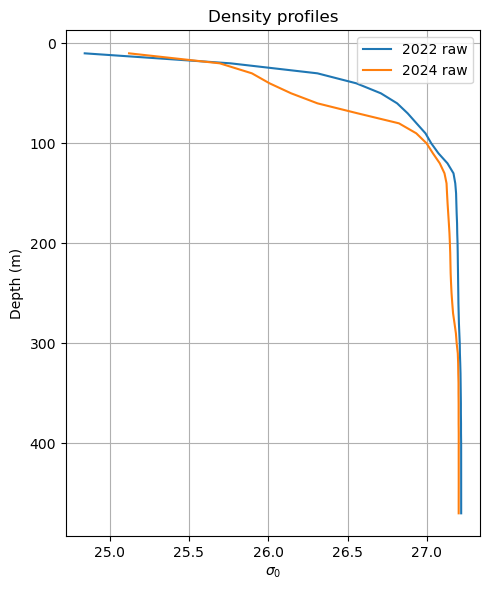

C:\Users\quzho2904\AppData\Local\Temp\ipykernel_21300\1836583380.py:148: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_term = np.trapz(integrand[valid], z_int[valid])



===== k(u) scan results =====
 u_depth_input  u_depth_actual          A_u  drho_dz_u  integral_term      k_u
           180           180.0 1.103156e+07   0.000392      -0.763582 0.000177
           190           190.0 1.032265e+07   0.000322      -0.678878 0.000204
           200           200.0 9.663060e+06   0.000244      -0.602247 0.000256
           210           210.0 9.106780e+06   0.000173      -0.531543 0.000338
           220           220.0 8.660759e+06   0.000134      -0.465714 0.000402
           230           230.0 8.282797e+06   0.000196      -0.403550 0.000249
           240           240.0 7.893084e+06   0.000281      -0.345560 0.000156
           250           250.0 7.557366e+06   0.000382      -0.292516 0.000101
           260           260.0 7.191126e+06   0.000477      -0.245275 0.000071
           270           270.0 6.855438e+06   0.000705      -0.204241 0.000042
           280           280.0 6.524442e+06   0.000895      -0.170853 0.000029
           290       

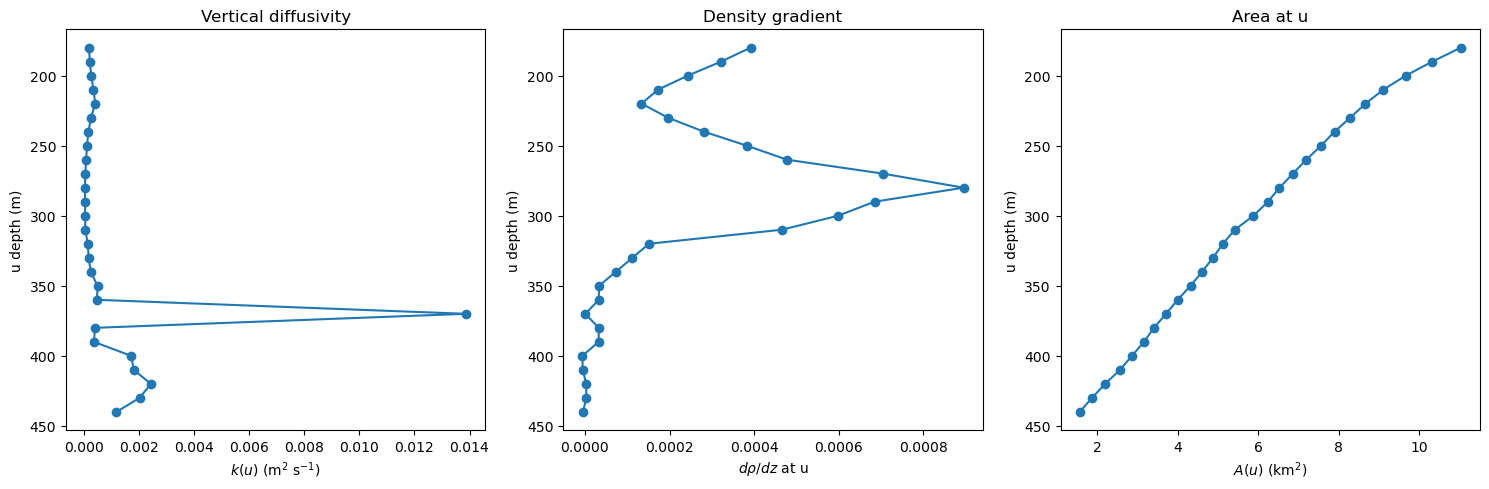

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. Load hypsometry
# =========================================================
def load_hypsometry_csv(hyp_csv):
    df = pd.read_csv(hyp_csv)

    required_cols = ["depth_m", "area_m2"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Hypsometry file missing column: {col}")

    z_hyp = df["depth_m"].to_numpy(dtype=float)
    area_z = df["area_m2"].to_numpy(dtype=float)

    volume_z = None
    if "volume_m3" in df.columns:
        volume_z = df["volume_m3"].to_numpy(dtype=float)

    idx = np.argsort(z_hyp)
    z_hyp = z_hyp[idx]
    area_z = area_z[idx]
    if volume_z is not None:
        volume_z = volume_z[idx]

    return z_hyp, area_z, volume_z, df


# =========================================================
# 2. Load sigma0 profile from single station
# =========================================================
def load_sigma_station_csv(sig_csv):
    df = pd.read_csv(sig_csv)

    required_cols = ["depth_m", "sigma0_2022", "sigma0_2024"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Sigma file missing column: {col}")

    z_obs = df["depth_m"].to_numpy(dtype=float)
    rho1 = df["sigma0_2022"].to_numpy(dtype=float)
    rho2 = df["sigma0_2024"].to_numpy(dtype=float)

    return z_obs, rho1, rho2, df


# =========================================================
# 3. Interpolate profile onto hypsometry grid
# =========================================================
def interp_profile_to_grid(z_obs, rho_obs, z_grid):
    z_obs = np.asarray(z_obs, dtype=float)
    rho_obs = np.asarray(rho_obs, dtype=float)
    z_grid = np.asarray(z_grid, dtype=float)

    mask = np.isfinite(z_obs) & np.isfinite(rho_obs)
    z_obs = z_obs[mask]
    rho_obs = rho_obs[mask]

    if len(z_obs) < 2:
        raise ValueError("Not enough valid observations for interpolation")

    idx = np.argsort(z_obs)
    z_obs = z_obs[idx]
    rho_obs = rho_obs[idx]

    rho_grid = np.interp(z_grid, z_obs, rho_obs, left=np.nan, right=np.nan)

    zmin = np.nanmin(z_obs)
    zmax = np.nanmax(z_obs)
    rho_grid[(z_grid < zmin) | (z_grid > zmax)] = np.nan

    return rho_grid


# =========================================================
# 4. Simple smoothing
# =========================================================
def moving_average_nan(x, window=3):
    x = np.asarray(x, dtype=float)
    y = np.full_like(x, np.nan)

    half = window // 2
    for i in range(len(x)):
        i0 = max(0, i - half)
        i1 = min(len(x), i + half + 1)
        seg = x[i0:i1]
        if np.isfinite(seg).sum() > 0:
            y[i] = np.nanmean(seg)

    return y


# =========================================================
# 5. Compute k for a single u depth
# =========================================================
def compute_vertical_diffusivity_single_u(
    z_grid,
    area_z,
    rho_t1,
    rho_t2,
    delta_t_days,
    u_depth,
    smooth_window=3,
    use_abs_value=True
):
    z_grid = np.asarray(z_grid, dtype=float)
    area_z = np.asarray(area_z, dtype=float)
    rho_t1 = np.asarray(rho_t1, dtype=float)
    rho_t2 = np.asarray(rho_t2, dtype=float)

    delta_t_sec = delta_t_days * 24 * 3600.0

    # time derivative of density
    drho_dt = (rho_t2 - rho_t1) / delta_t_sec

    # find nearest u depth
    u_index = np.argmin(np.abs(z_grid - u_depth))
    u_depth_actual = z_grid[u_index]

    # vertical density gradient
    drho_dz = np.gradient(rho_t2, z_grid)
    drho_dz_u = drho_dz[u_index]

    # basin area at u
    A_u = area_z[u_index]

    # integrate below u
    mask_int = z_grid >= u_depth_actual
    z_int = z_grid[mask_int]
    integrand = area_z[mask_int] * drho_dt[mask_int]

    valid = np.isfinite(z_int) & np.isfinite(integrand)

    if valid.sum() < 2:
        return {
            "u_depth_input": u_depth,
            "u_depth_actual": u_depth_actual,
            "A_u": A_u,
            "drho_dz_u": drho_dz_u,
            "integral_term": np.nan,
            "k_u": np.nan
        }

    integral_term = np.trapz(integrand[valid], z_int[valid])

    denominator = A_u * drho_dz_u

    if (not np.isfinite(denominator)) or (denominator == 0):
        k_u = np.nan
    else:
        k_u = integral_term / denominator
        if use_abs_value:
            k_u = np.abs(k_u)

    return {
        "u_depth_input": u_depth,
        "u_depth_actual": u_depth_actual,
        "A_u": A_u,
        "drho_dz_u": drho_dz_u,
        "integral_term": integral_term,
        "k_u": k_u
    }


# =========================================================
# 6. Scan multiple u depths
# =========================================================
def scan_u_depths(
    z_grid,
    area_z,
    rho_t1,
    rho_t2,
    delta_t_days,
    u_depth_list,
    smooth_window=3,
    use_abs_value=True
):
    results = []

    for u in u_depth_list:
        res = compute_vertical_diffusivity_single_u(
            z_grid=z_grid,
            area_z=area_z,
            rho_t1=rho_t1,
            rho_t2=rho_t2,
            delta_t_days=delta_t_days,
            u_depth=u,
            smooth_window=smooth_window,
            use_abs_value=use_abs_value
        )
        results.append(res)

    df = pd.DataFrame(results)
    return df


# =========================================================
# 7. Plot density profiles
# =========================================================
def plot_density_profiles(z_grid, rho1_grid, rho2_grid, smooth_window=3):
    rho1_s = moving_average_nan(rho1_grid, window=smooth_window)
    rho2_s = moving_average_nan(rho2_grid, window=smooth_window)

    plt.figure(figsize=(5, 6))
    plt.plot(rho1_grid, z_grid, label="2022 raw")
    plt.plot(rho2_grid, z_grid, label="2024 raw")

    plt.gca().invert_yaxis()
    plt.xlabel(r"$\sigma_0$")
    plt.ylabel("Depth (m)")
    plt.title("Density profiles")

    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


# =========================================================
# 8. Plot scan results
# =========================================================
def plot_scan_results(df_scan):

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # k(u)
    axes[0].plot(df_scan["k_u"], df_scan["u_depth_actual"], "o-")
    axes[0].invert_yaxis()
    axes[0].set_xlabel(r"$k(u)$ (m$^2$ s$^{-1}$)")
    axes[0].set_ylabel("u depth (m)")
    axes[0].set_title("Vertical diffusivity")

    # density gradient
    axes[1].plot(df_scan["drho_dz_u"], df_scan["u_depth_actual"], "o-")
    axes[1].invert_yaxis()
    axes[1].set_xlabel(r"$d\rho/dz$ at u")
    axes[1].set_ylabel("u depth (m)")
    axes[1].set_title("Density gradient")

    # area
    axes[2].plot(df_scan["A_u"] / 1e6, df_scan["u_depth_actual"], "o-")
    axes[2].invert_yaxis()
    axes[2].set_xlabel(r"$A(u)$ (km$^2$)")
    axes[2].set_ylabel("u depth (m)")
    axes[2].set_title("Area at u")

    plt.tight_layout()
    plt.show()


# =========================================================
# 9. Main program
# =========================================================
if __name__ == "__main__":

    # -----------------------------------------------------
    # File paths
    # -----------------------------------------------------
    hyp_csv = r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\hypsometry_dz10m_lonLE5.30.csv"

    sig_csv = r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\sigma0_station135_2022_vs_station15_2024.csv"

    # -----------------------------------------------------
    # Load data
    # -----------------------------------------------------
    z_hyp, area_z, volume_z, df_hyp = load_hypsometry_csv(hyp_csv)

    z_obs, rho1_obs, rho2_obs, df_sig = load_sigma_station_csv(sig_csv)

    # -----------------------------------------------------
    # Interpolate onto hypsometry grid
    # -----------------------------------------------------
    rho1_grid = interp_profile_to_grid(z_obs, rho1_obs, z_hyp)

    rho2_grid = interp_profile_to_grid(z_obs, rho2_obs, z_hyp)

    # -----------------------------------------------------
    # Parameters
    # -----------------------------------------------------
    delta_t_days = 735.0
    smooth_window = 3

    u_depth_list = np.arange(180, 450, 10)

    # -----------------------------------------------------
    # Plot profiles
    # -----------------------------------------------------
    plot_density_profiles(z_hyp, rho1_grid, rho2_grid,
                          smooth_window=smooth_window)

    # -----------------------------------------------------
    # Scan multiple u depths
    # -----------------------------------------------------
    df_scan = scan_u_depths(
        z_grid=z_hyp,
        area_z=area_z,
        rho_t1=rho1_grid,
        rho_t2=rho2_grid,
        delta_t_days=delta_t_days,
        u_depth_list=u_depth_list,
        smooth_window=smooth_window,
        use_abs_value=True
    )

    # -----------------------------------------------------
    # Print results
    # -----------------------------------------------------
    print("\n===== k(u) scan results =====")
    print(df_scan.to_string(index=False))

    # -----------------------------------------------------
    # Save results
    # -----------------------------------------------------
    save_csv = r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\mixing_scan_u_station135_2022_vs_station15_2024.csv"

    df_scan.to_csv(save_csv, index=False, encoding="utf-8-sig")

    print(f"\nSaved scan results to:\n{save_csv}")

    # -----------------------------------------------------
    # Plot scan results
    # -----------------------------------------------------
    plot_scan_results(df_scan)